# Victoria Grid Data

The **MGA Graticule 1km** shapefile represents a 1km interval grid over Victoria in the MGA (Map Grid of Australia) projection. We use it as the base spatial reference for all downstream feature engineering.

## Imports

In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import numpy as np
from rasterio.transform import rowcol

## Load Data

In [4]:
gdf = gpd.read_file("GRAT_MGA_1K.shp")

print("Shape:", gdf.shape)
print("Columns:", gdf.columns.tolist())
print("Dtypes:\n", gdf.dtypes)

Shape: (8653, 9)
Columns: ['LABEL', 'GREF_FULL', 'FIG_LARGE', 'FIG_THREE', 'FIG_SMALL', 'SIGNIF', 'LENGTHM', 'DIRECTION', 'geometry']
Dtypes:
 LABEL             str
GREF_FULL       int64
FIG_LARGE         str
FIG_THREE         str
FIG_SMALL       int32
SIGNIF          int32
LENGTHM       float64
DIRECTION         str
geometry     geometry
dtype: object


| Column | Type | Description |
|---|---|---|
| `LABEL` | string | Grid line label |
| `GREF_FULL` | int | Full grid reference number |
| `FIG_LARGE` | string | Large-figure grid reference |
| `FIG_THREE` | string | Three-figure grid reference |
| `FIG_SMALL` | int | 1 km grid interval value |
| `SIGNIF` | int | Display priority level |
| `LENGTHM` | float | Line length in metres |
| `DIRECTION` | string | `E` = Easting (vertical) / `S` = Southing (horizontal) |
| `geometry` | LineString | Line geometry (EPSG:7899) |

## Convert to DF

We reproject from **EPSG:7899** (GDA2020 / Vicgrid, metres) to **EPSG:4326** (WGS84, lat/lon degrees) so coordinates are usable on standard maps and joinable with external datasets.

Each `LineString` geometry contains a sequence of `(x, y)` vertices, after reprojection `x = longitude`, `y = latitude`. We unpack those into rows and drop duplicates to get a clean flat coordinate table.

We create **3 filtered versions** using `SIGNIF` (grid line significance level) to control density:
- **1 km** → all lines, full resolution
- **5 km** → major grid lines only
- **10 km** → coarsest grid, useful for large-scale modelling

In [5]:
print(gdf["SIGNIF"].value_counts().sort_index())

SIGNIF
1      6902
5       874
10      701
50       83
100      93
Name: count, dtype: int64


In [6]:
gdf = gdf.set_crs(epsg=7899)
gdf = gdf.to_crs(epsg=4326)

def to_df(gdf_filtered):
    coords = [(y, x) for geom in gdf_filtered.geometry if geom for x, y in geom.coords]
    return pd.DataFrame(coords, columns=["lat", "lon"]).drop_duplicates().reset_index(drop=True)

df_1km = to_df(gdf)
df_5km = to_df(gdf[gdf["SIGNIF"] >= 5])
df_10km = to_df(gdf[gdf["SIGNIF"] >= 10])

print(f"1km points: {len(df_1km):,}")
print(f"5km points: {len(df_5km):,}")
print(f"10km points: {len(df_10km):,}")

1km points: 463,806
5km points: 166,295
10km points: 87,734


## Visualize

Denser grids capture more spatial detail but are heavier to process.

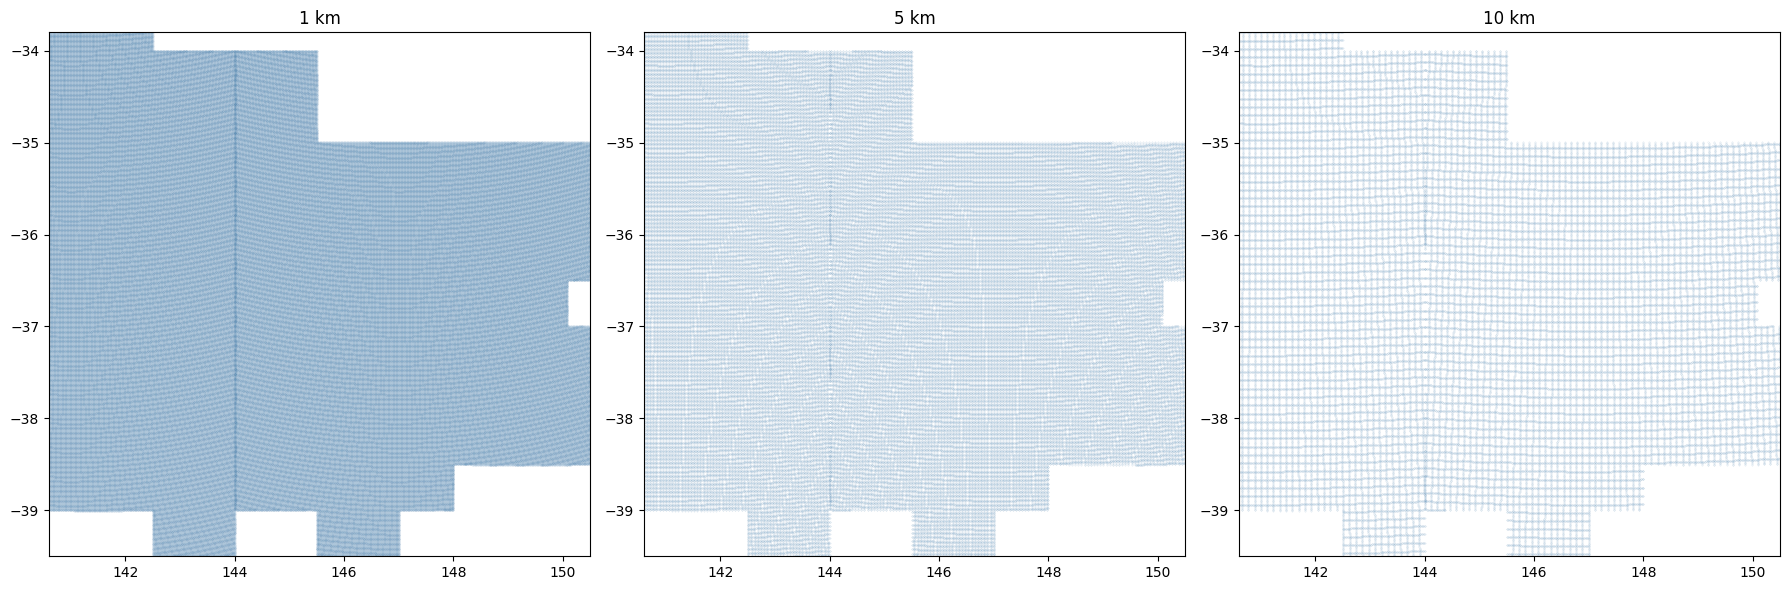

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, df, title in zip(axes, [df_1km, df_5km, df_10km], ["1 km", "5 km", "10 km"]):
    ax.scatter(df["lon"], df["lat"], s=0.01, color="steelblue", alpha=0.5)
    ax.set_title(title)
    ax.set_xlim([140.6, 150.5])
    ax.set_ylim([-39.5, -33.8])

plt.tight_layout()
plt.show()

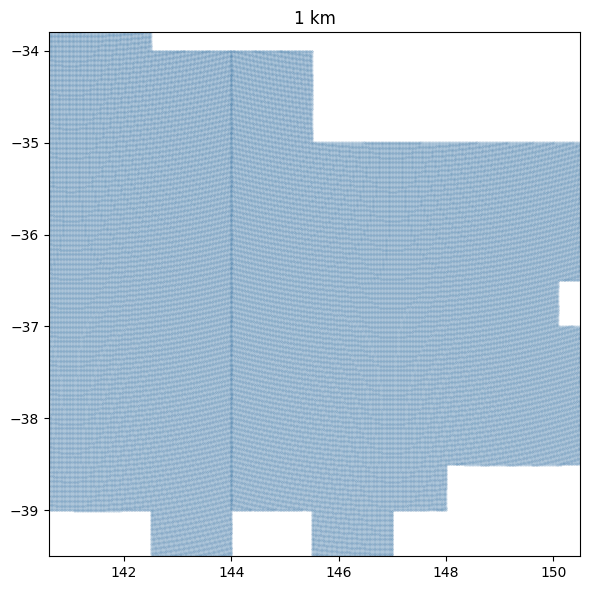

In [8]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(df_1km["lon"], df_1km["lat"], s=0.01, color="steelblue", alpha=0.5)
ax.set_title("1 km")
ax.set_xlim([140.6, 150.5])
ax.set_ylim([-39.5, -33.8])

plt.tight_layout()
plt.show()

Postcodes

We spatial join the 1km grid coordinates against the **ABS Postal Area (POA) 2021** boundaries (GDA2020) to assign a postcode to each grid point. This allows downstream aggregation and analysis at the postcode level.

## Load Data

In [7]:
poa = gpd.read_file("POA_2021_AUST_GDA2020.shp")
poa = poa.set_crs(epsg=4326)
poa = poa[["POA_CODE21", "geometry"]].rename(columns={"POA_CODE21": "postcode"})

## Spatial Join

Each grid point is matched to the postcode polygon it falls within. Points outside any POA boundary (e.g. state borders, ocean edges) will have `NaN` postcode.

In [8]:
gdf_pts = gpd.GeoDataFrame(
    df_1km,
    geometry=gpd.points_from_xy(df_1km["lon"], df_1km["lat"]),
    crs="EPSG:4326"
)

gdf_joined = gpd.sjoin(gdf_pts, poa, how="left", predicate="within")

df_postcode = gdf_joined[["lat", "lon", "postcode"]].reset_index(drop=True)

## Visualize

POA boundaries overlaid with grid points coloured by postcode. Victorian postcodes all begin with `3`.

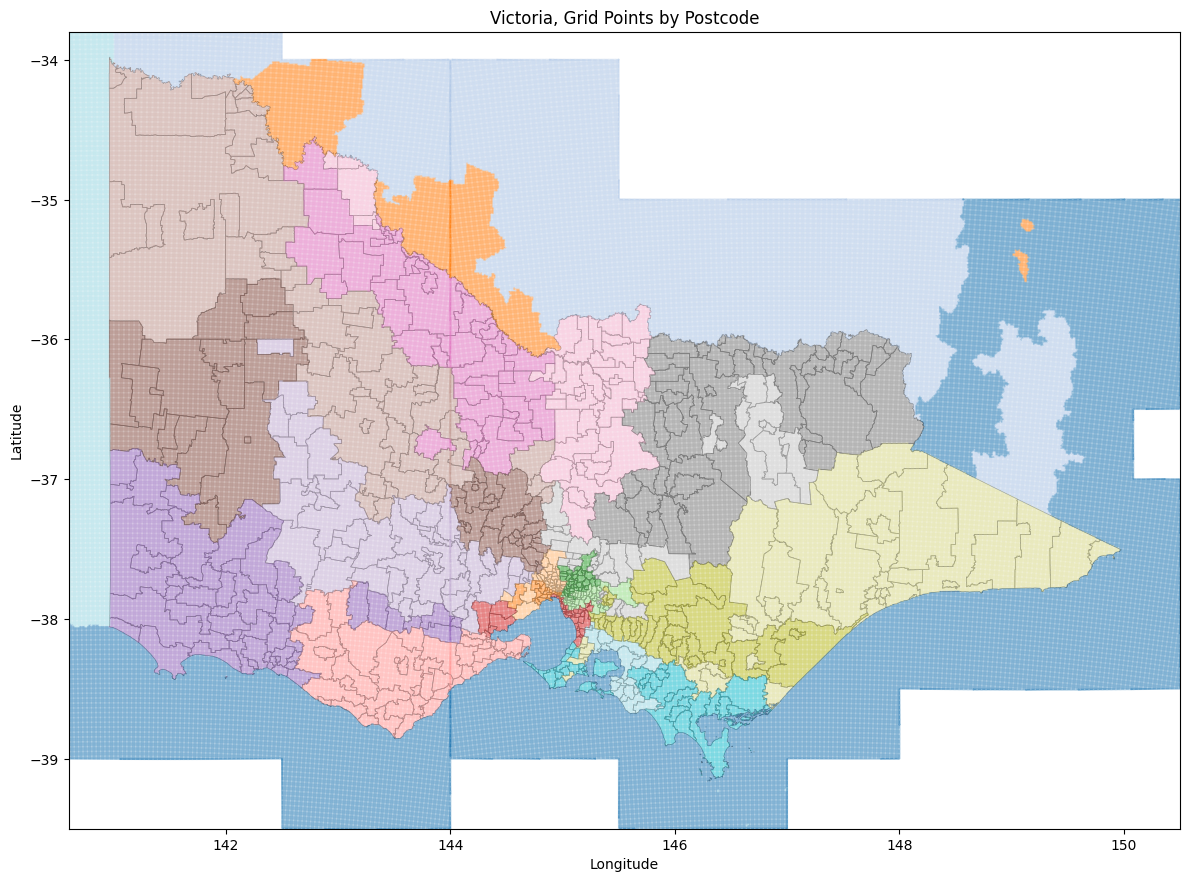

In [9]:
fig, ax = plt.subplots(figsize=(12, 10))

poa_vic = poa[poa["postcode"].str.startswith("3")]
poa_vic.plot(ax=ax, edgecolor="gray", facecolor="none", linewidth=0.5)

scatter = ax.scatter(
    df_postcode["lon"],
    df_postcode["lat"],
    s=0.1,
    c=df_postcode["postcode"].astype("category").cat.codes,
    cmap="tab20",
    alpha=0.5,
)

ax.set_xlim([140.6, 150.5])
ax.set_ylim([-39.5, -33.8])
ax.set_title("Victoria, Grid Points by Postcode")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [10]:
df_postcode.to_csv("victoria_grid_1km.csv", index=False)